In [10]:
import pandas as pd
from sklearn.impute import SimpleImputer

dframe = pd.read_csv("filtered-dataset.csv")

#check for missing columns
missing_columns = dframe.columns[dframe.isnull().any()].tolist()
print("MISSING COLUMN BEFORE IMPUTATION")
print(missing_columns)
print()

stats = dframe[(missing_columns)].describe()

#Add median row
median_row = pd.DataFrame(dframe[missing_columns].median(), columns = ['median']).T
stats = pd.concat([stats,median_row])

print(f"STATISTICS OF COLUMNS WITH MISSING DATA")
print(stats.round(2).to_string())

#Fill missing cells with mean value of the column
imputer = SimpleImputer(strategy="median")
dframe[missing_columns] = imputer.fit_transform(dframe[missing_columns])
    
#Count remaining missing columns
remaining_missing_col = dframe.isnull().sum().sum()
print(f"Total missing cells after filling is: {remaining_missing_col}")

#Save as another csv file
filename_output = "processed-dataset.csv"
dframe.to_csv(filename_output,index = False)
print(f"This is the dataset for the next process.")

MISSING COLUMN BEFORE IMPUTATION
['Perceived_Stress_Score', 'Academic_Performance_GPA']

STATISTICS OF COLUMNS WITH MISSING DATA
        Perceived_Stress_Score  Academic_Performance_GPA
count                  4454.00                   4415.00
mean                     13.51                      3.43
std                       7.07                      0.39
min                       0.00                      1.90
25%                       9.00                      3.20
50%                      13.00                      3.46
75%                      18.00                      3.72
max                      40.00                      4.00
median                   13.00                      3.46
Total missing cells after filling is: 0
This is the dataset for the next process.


DATASET STATISTIC COMPARISON BETWEEN THE ORIGINAL AND THE PROCESSED

 Feature: Perceived_Stress_Score
      Original  Processed  Difference
mean   13.5121    13.5069     -0.0052
std     7.0729     7.0368     -0.0361
min     0.0000     0.0000      0.0000
50%    13.0000    13.0000      0.0000
max    40.0000    40.0000      0.0000

 Feature: Academic_Performance_GPA
      Original  Processed  Difference
mean    3.4293     3.4299      0.0006
std     0.3927     0.3890     -0.0037
min     1.9000     1.9000      0.0000
50%     3.4600     3.4600      0.0000
max     4.0000     4.0000      0.0000
Distribution plot saved at Asset/imputation_comparison_kde_processed.png


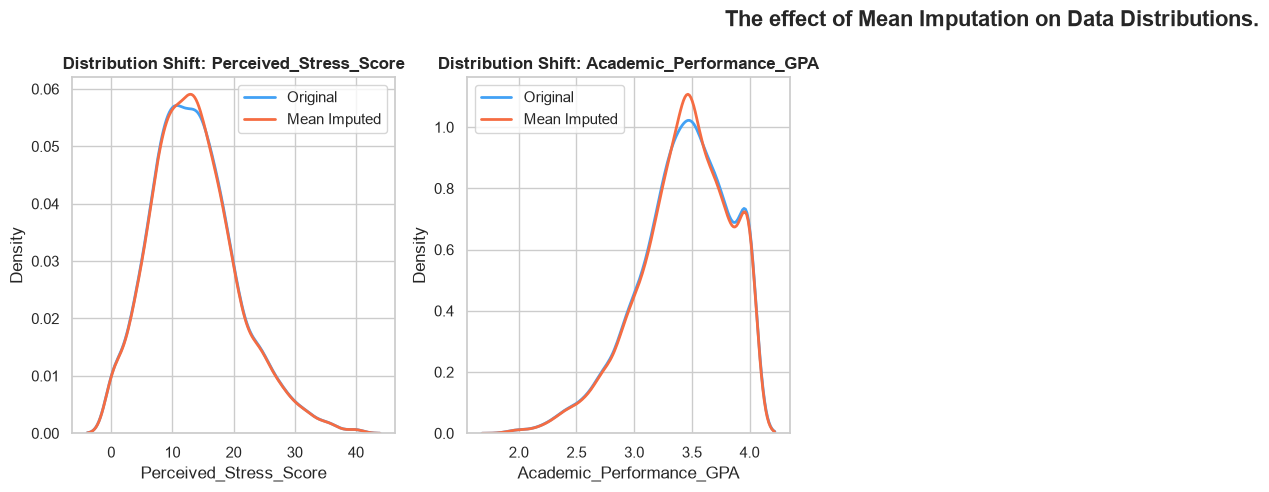

In [11]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dframe_before = pd.read_csv("filtered-dataset.csv")
dframe_proc = pd.read_csv("processed-dataset.csv")

output_dir = "Asset/"
os.makedirs(output_dir, exist_ok=True)

imputed_cols = dframe_before.columns[dframe_before.isnull().any()].tolist()
num_imputed = len(imputed_cols)

if num_imputed == 0:
    print("No missing values found in the original dataset. No comparison needed")
else:
    print("DATASET STATISTIC COMPARISON BETWEEN THE ORIGINAL AND THE PROCESSED")
    # Describe for the comparison plot
    for col in imputed_cols:
        before_stats = dframe_before[col].describe()
        proc_stats = dframe_proc[col].describe()
    
        cmp_dframe = pd.DataFrame({
            'Original' : before_stats,
            'Processed' : proc_stats,
            'Difference' : proc_stats - before_stats
        }).loc[['mean','std','min','50%','max']]
        print(f"\n Feature: {col}")
        print(cmp_dframe.round(4).to_string())
    

#Declare rows,cols for drawing plot
plot_cols = 5
plot_rows = math.ceil(num_imputed / plot_cols)
fig, axes = plt.subplots(nrows=plot_rows,ncols=plot_cols, figsize=(20,5*plot_rows))
axes = axes.flatten() if num_imputed > 1 else [axes]
sns.set_theme(style="whitegrid")

for idx,col in enumerate(imputed_cols):
    sns.kdeplot(dframe_before[col].dropna(), color='#42a1f5', label='Original',ax=axes[idx], linewidth=2)
    sns.kdeplot(dframe_proc[col],color='#f56c42',linestyle='-', label='Mean Imputed',ax=axes[idx], linewidth=2)
    
    axes[idx].set_title(f'Distribution Shift: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

for i in range(num_imputed,len(axes)):
    fig.delaxes(axes[i])
plt.suptitle('The effect of Mean Imputation on Data Distributions.',fontsize=16,fontweight='bold')
plt.tight_layout()

#Save as png
cmp_image_name = 'imputation_comparison_kde_processed.png'
cmp_image_path = os.path.join(output_dir,cmp_image_name)
plt.savefig(cmp_image_path, dpi=400, bbox_inches='tight')
print(f"Distribution plot saved at {cmp_image_path}")


In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

dframe = pd.read_csv('processed-dataset.csv')

print("DATASET BEFORE ENCODING")
print(dframe.head(3))

ordinal_mapping = {
    'Late_Night_Usage': {False: 0, True: 1},
    'Overall_Impact': {'Negative': 0, 'Neutral': 1, 'Beneficial': 2},
    'Social_Comparison_Frequency' : {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Frequently' : 3, 'Always' : 4}
}

for col, mapping in ordinal_mapping.items():
    if col in dframe.columns:
        dframe[col] = dframe[col].map(mapping)
        
le = LabelEncoder()
label_cols = ['Academic_Level', 'Gender', 'Primary_Platform', 'Device_Type']

for col in label_cols:
    if col in dframe.columns:
        
        dframe[col] = le.fit_transform(dframe[col])
        mapping_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"Label Mapping for '{col}': {mapping_dict}")

print("\n DATA AFTER ENCODING")
print(dframe.info())

output_file = 'scaling-dataset.csv'
dframe.to_csv(output_file, index=False)
print(f"\nData successfully encoded and saved to: '{output_file}'")

DATASET BEFORE ENCODING
    Student_ID  Age  Gender Academic_Level Primary_Platform  \
0  STU_2024000   19  Female  Undergraduate         Snapchat   
1  STU_2024001   19  Female  Undergraduate        Instagram   
2  STU_2024002   17  Female    High School           TikTok   

   Daily_Usage_Hours  Weekend_Extra_Hours Device_Type  Sleep_Duration_Hours  \
0                7.5                  1.5  Smartphone                   5.9   
1                4.6                  1.3  Smartphone                   7.9   
2               10.9                  1.7  Smartphone                   5.2   

   Sleep_Quality_Score  Late_Night_Usage Social_Comparison_Frequency  \
0                    2              True                      Always   
1                    3              True                   Sometimes   
2                    1              True                  Frequently   

   Perceived_Stress_Score  Mental_Health_Index  Academic_Performance_GPA  \
0                    20.0                